In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("train.csv")
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [3]:
df = df.drop(columns=["Cabin", "Ticket", "Name", "PassengerId"])

In [4]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [5]:
numeric_features = ["Age", "Fare", "SibSp", "Parch"]
categorical_features = ["Sex", "Embarked", "Pclass"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


In [6]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [7]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    "classifier__max_depth": [3, 5, 7, 9, None],
    "classifier__min_samples_split": [2, 5, 10]
}

dt_grid = GridSearchCV(dt_pipeline, dt_param_grid, cv=5, scoring="accuracy")
dt_grid.fit(X, y)

print("best Decision Tree params:", dt_grid.best_params_)
print("bestt Decision Tree CV accuracy:", dt_grid.best_score_)

best Decision Tree params: {'classifier__max_depth': 9, 'classifier__min_samples_split': 2}
bestt Decision Tree CV accuracy: 0.8159500345238844


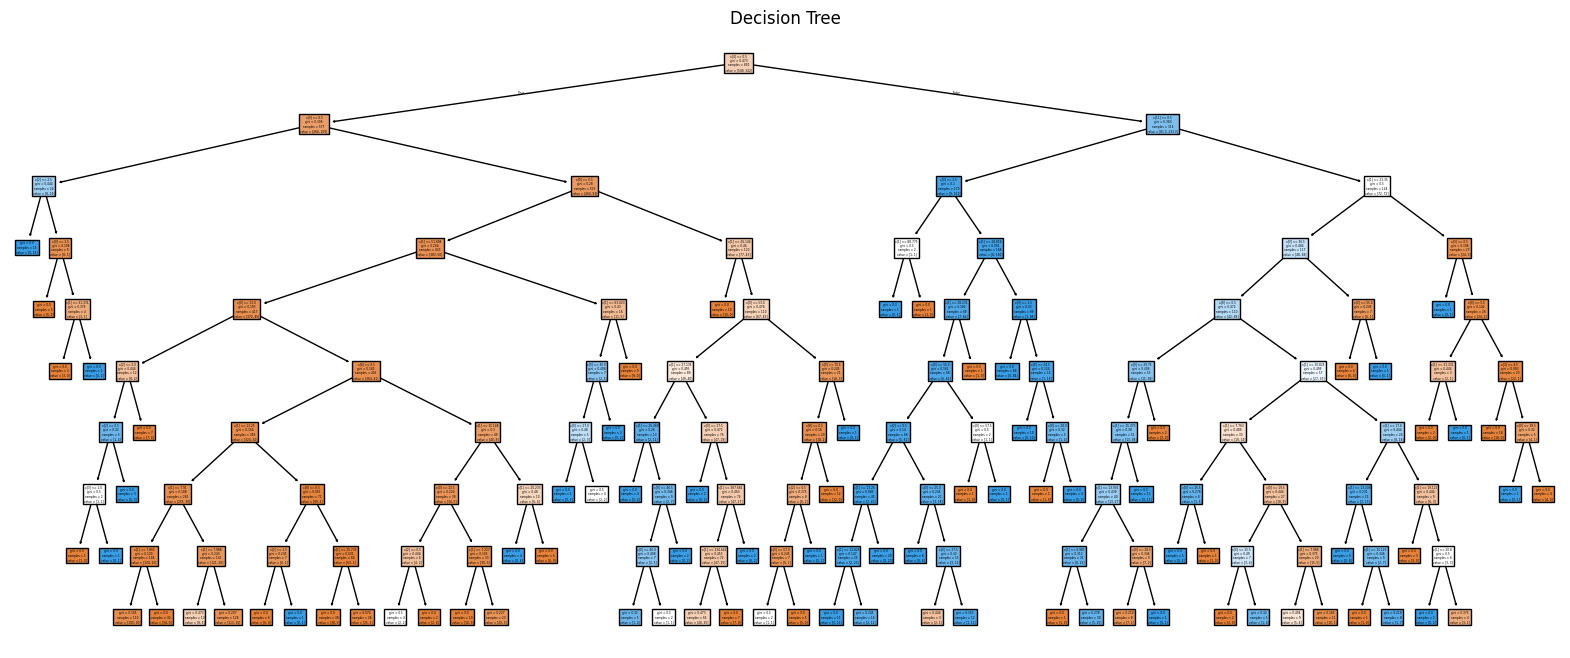

In [8]:
best_dt = dt_grid.best_estimator_

dt_model = best_dt.named_steps["classifier"]

plt.figure(figsize=(20, 8))
plot_tree(dt_model, filled=True)
plt.title("Decision Tree")
plt.savefig("decision_tree.png", dpi=150)
plt.show()
plt.close()


In [9]:
dt_scores = cross_val_score(best_dt, X, y, cv=5, scoring="accuracy")
print("\ndecision tree accuracy:", dt_scores.mean(), "+/-", dt_scores.std())




decision tree accuracy: 0.8159500345238844 +/- 0.018457471771929523


In [10]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring="accuracy")
rf_grid.fit(X, y)

print("\nbest Random Forest Params:", rf_grid.best_params_)
print("best Random Forest CV Accuracy:", rf_grid.best_score_)


best Random Forest Params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
best Random Forest CV Accuracy: 0.8294269035214363


In [11]:
best_rf = rf_grid.best_estimator_
rf_scores = cross_val_score(best_rf, X, y, cv=5, scoring="accuracy")

print("\nRandom Forest Accuracy:", rf_scores.mean(), "+/-", rf_scores.std())



Random Forest Accuracy: 0.8294269035214363 +/- 0.03216126684855892


In [12]:
print("\n--- Final Comparison ---")
print(f"decision Tree : {dt_scores.mean():.4f}")
print(f"random Forest : {rf_scores.mean():.4f}")

if rf_scores.mean() > dt_scores.mean():
    print("conclusion: Random Forest performs better due to reduced overfitting.")
else:
    print("conclusion: Decision Tree performs better (simpler model).")



--- Final Comparison ---
decision Tree : 0.8160
random Forest : 0.8294
conclusion: Random Forest performs better due to reduced overfitting.
